In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 

In [13]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

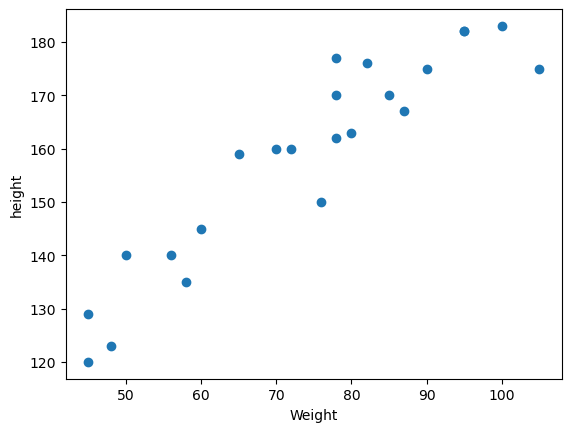

In [14]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("height")

In [44]:
## s-1 :-divide the dataset into dependent and independent
x=df[['Weight']]
y=df['Height']


In [45]:
#s-2:- train test split 
from sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [47]:
#S-3:-STANDARDIZATION OF THE DATASET TRAIN INDEPENDENT DATA 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

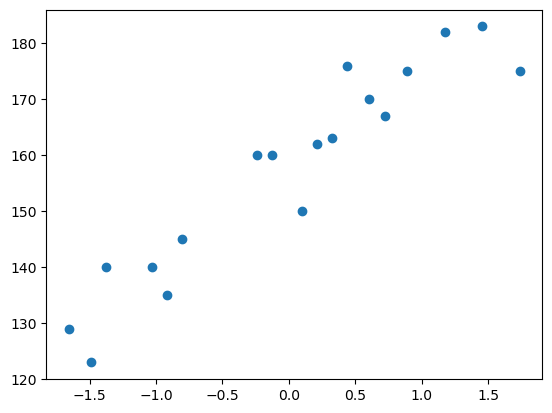

In [48]:
plt.scatter(x_train,y_train)

In [53]:
#s-4:-simple linear regression model
from sklearn.linear_model import LinearRegression
regressor =LinearRegression()

In [60]:
regressor.fit(x_train,y_train)
print('fitted successfully')

fitted successfully


In [65]:
print("the slope or coefficent of the weight is ",regressor.coef_)
print("intercept :",regressor.intercept_)

the slope or coefficent of the weight is  [17.03440872]
intercept : 157.5


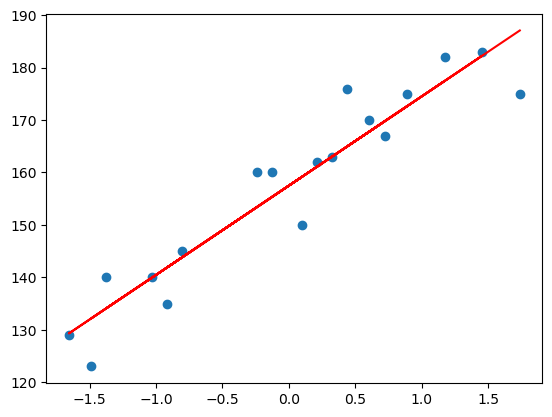

In [66]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),color="red")

In [68]:
y_pred=regressor.predict(x_test)

In [69]:
##performance metrics:
#mse,mae,rmse
#r_squared and adjusted r_squared
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


109.77592599051664
9.822657814519232
10.477400726827081


In [78]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("r2:",score)
adjusted_r2_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print("adjusted r2 :",adjusted_r2_score)

r2: 0.776986986042344
adjusted r2 : 0.7026493147231252


In [79]:
#new datapoint weight is 80
scaled_weight=scaler.transform([[80]])
scaled_weight

C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [80]:
print(regressor.predict([scaled_weight[0]]))

[163.01076266]
